# PZ data challenge: results across all task sets

This notebook puts the results of the four task-set notebooks (`pz_challenge_taskset{1..4}_e2e.ipynb`) side by side. It covers all 16 configurations: 4 task sets × 2 sims × 2 depths. It reads what those notebooks wrote to `OUT_DIR` (`outputs/znn` from scratch, `outputs/znn_pretrained_popcosmos` with pre-training; set by `PRETRAINING`) and trains nothing.

- **Part A, test-set p(z)** (the subtask 1 files): what we submit. The test redshifts are hidden, so this part only shows the predictions, i.e. the implied n(z) and the p(z) widths, set against the training redshift distribution.
- **Part B, held-out scores** (the subtask 2 model files): each `.pkl` is reloaded and run on the same held-out split the task-set notebook used (`train_test_split` with `VAL_FRAC` and `SEED`). The results are scored with the challenge metrics and tiers. Predictions use the same photometric resampling as the submission (`N_SAMPLES` draws). The noise stream is not identical to the e2e run, so the numbers can differ from those notebooks in the last digit.

The held-out predictions are cached in `CACHE_DIR`, outside `OUT_DIR` so they stay out of the submission tarball. Delete the cache to recompute.

Run this from the repo root with the `qp` conda env as the kernel.

Plot conventions: **colour = depth** (blue 10yr, orange 1yr) and **line style = sim** (solid Cardinal, dashed Flagship).

## Configuration

In [ ]:
import znn  # run from the repo root so this picks up the local source

TASKSETS = [1, 2, 3, 4]
SIMS = ["cardinal", "flagship"]
SCENARIOS = ["1yr", "10yr"]
TASKSET_NAMES = {
    1: "1: representative",
    2: "2: spec-selected",
    3: "3: spec + COSMOS",
    4: "4: spec + COSMOS, blended",
}

DATA_DIR = "pz_data_challenge/tests/public"
# Which run to read; must match the task-set notebooks: "popcosmos" (the pre-training shipped with znn) or None (from scratch). Each choice
# writes to its own directory, so runs with and without pre-training never overwrite each other.
PRETRAINING = "popcosmos"
OUT_DIR = "outputs/znn" if PRETRAINING is None else f"outputs/znn_pretrained_{PRETRAINING}"  # the submission files written by the task-set notebooks
CACHE_DIR = f"{OUT_DIR}_heldout"  # held-out predictions of part B

# must match the task-set notebooks
VAL_FRAC = 0.2
SEED = 42
N_SAMPLES = 50
NOISE_SEED = 42

In [ ]:
import itertools
import os

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from qp.metrics.pit import PIT
from scipy.stats import norm
from sklearn.model_selection import train_test_split

from pz_data_challenge import scoring

os.makedirs(CACHE_DIR, exist_ok=True)

CONFIGS = list(itertools.product(TASKSETS, SIMS, SCENARIOS))
COLORS = {"10yr": "#2a78d6", "1yr": "#eb6834"}
LINESTYLES = {"cardinal": "-", "flagship": "--"}
TRAIN_COLOR = "0.6"


def style(sim, scenario):
    return dict(color=COLORS[scenario], ls=LINESTYLES[sim], lw=1.5, label=f"{sim} {scenario}")


def path(kind, taskset, sim, scenario):
    if kind in ("training", "test"):
        return os.path.join(DATA_DIR, f"pz_challenge_taskset_{taskset}_{sim}_{kind}_{scenario}.hdf5")
    ext = "hdf5" if kind == "pz_estimate" else "pkl"
    return os.path.join(OUT_DIR, f"pz_challenge_taskset_{taskset}_{sim}_{kind}_{scenario}.{ext}")


missing = [p for c in CONFIGS for k in ("pz_estimate", "pz_model") if not os.path.exists(p := path(k, *c))]
assert not missing, f"missing submission files: {missing}"

## Reference redshifts

These are the same labels as in the task-set notebooks. Task sets 1 and 2 use `redshift`. Task sets 3 and 4 use `redshift` for spectroscopically selected objects and `redshift_manyband` for COSMOS-only objects, so scores on the COSMOS-only objects include the label noise.

In [ ]:
SPEC_SURVEYS = ["DEEP2_LSST", "DESI_BGS", "DESI_ELG_LOP", "DESI_LRG", "VVDSf02", "zCOSMOS"]


def reference_redshifts(train):
    # Reference redshift per training object, and the held-out subsets to score (masks over train).
    z_spec = train["redshift"].to_numpy()
    if "COSMOS" not in train:  # task sets 1 and 2
        subsets = {"all": np.ones(len(train), dtype=bool)}
        if (train["mag_i_lsst"] < 23.5).all():
            return z_spec, subsets  # task set 1
        return z_spec, subsets | {"i > 23": train["mag_i_lsst"].to_numpy() > 23}  # task set 2

    is_spec = train[[c for c in SPEC_SURVEYS if c in train]].astype(bool).any(axis=1).to_numpy()
    is_cosmos_only = train["COSMOS"].astype(bool).to_numpy() & ~is_spec
    z_ref = np.where(is_cosmos_only, train["redshift_manyband"].to_numpy(), z_spec)
    assert np.isfinite(z_ref).all()
    return z_ref, {"all": np.ones(len(train), dtype=bool), "spec": is_spec, "COSMOS-only": is_cosmos_only}

# Part A: test-set p(z)

Each subtask 1 file is a qp ensemble of Gaussians (`data/loc`, `data/scale`). Each is matched to its test catalogue by `object_id` to pick up the i-band magnitude.

In [ ]:
def read_estimate(taskset, sim, scenario):
    with h5py.File(path("pz_estimate", taskset, sim, scenario)) as f:
        est = pd.DataFrame(
            {
                "object_id": f["ancil/object_id"][:],
                "mean": f["data/loc"][:, 0],
                "std": f["data/scale"][:, 0],
            }
        )
    test = znn.read_catalog(path("test", taskset, sim, scenario), columns=["object_id", "mag_i_lsst"])
    est = est.merge(test, on="object_id", how="left", validate="one_to_one")
    assert est["mag_i_lsst"].notna().all()
    return est


estimates, train_z = {}, {}
for c in CONFIGS:
    estimates[c] = read_estimate(*c)
    train = znn.read_catalog(path("training", *c))
    train_z[c], _ = reference_redshifts(train)

summary = pd.DataFrame(
    {
        c: {
            "N test": len(e),
            "median z": e["mean"].median(),
            "median σ": e["std"].median(),
            "median σ/(1+z)": (e["std"] / (1 + e["mean"])).median(),
            "frac z < 0": (e["mean"] < 0).mean(),
            "frac mass at z < 0": norm.cdf(0, e["mean"], e["std"]).mean(),
            "median i (test)": e["mag_i_lsst"].median(),
        }
        for c, e in estimates.items()
    }
).T
summary.index.names = ["taskset", "sim", "scenario"]
summary.round(4)

N test  median z  median σ  median σ/(1+z)  \
taskset sim      scenario                                                
1       cardinal 1yr       20000.0    0.5523    0.0205          0.0130   
                 10yr      20000.0    0.5496    0.0135          0.0086   
        flagship 1yr       20000.0    0.5761    0.0223          0.0138   
                 10yr      20000.0    0.5744    0.0129          0.0079   
2       cardinal 1yr       20000.0    0.8153    0.1298          0.0681   
                 10yr      20000.0    0.7700    0.0667          0.0352   
        flagship 1yr       20000.0    0.8900    0.1366          0.0690   
                 10yr      20000.0    0.8759    0.0637          0.0310   
3       cardinal 1yr       20000.0    0.7738    0.0867          0.0464   
                 10yr      20000.0    0.7775    0.0510          0.0269   
        flagship 1yr       20000.0    0.8911    0.0902          0.0459   
                 10yr      20000.0    0.8798    0.0498          0.0245   
4       cardinal 1yr       20000.0    0.7678    0.0875          0.0472   
                 10yr      20000.0    0.7614    0.0520          0.0277   
        flagship 1yr       20000.0    0.9026    0.1066          0.0547   
                 10yr      20000.0    0.8933    0.0555          0.0275   

                           frac z < 0  frac mass at z < 0  median i (test)  
taskset sim      scenario                                                   
1       cardinal 1yr              0.0              0.0003          22.1072  
                 10yr             0.0              0.0000          22.0959  
        flagship 1yr              0.0              0.0003          22.1419  
                 10yr             0.0              0.0000          22.1341  
2       cardinal 1yr              0.0              0.0032          24.2720  
                 10yr             0.0              0.0028          24.4045  
        flagship 1yr              0.0              0.0038          24.3710  
                 10yr             0.0              0.0025          24.4985  
3       cardinal 1yr              0.0              0.0005          24.2496  
                 10yr             0.0              0.0004          24.3529  
        flagship 1yr              0.0              0.0011          24.3351  
                 10yr             0.0              0.0010          24.4402  
4       cardinal 1yr              0.0              0.0004          24.2115  
                 10yr             0.0              0.0005          24.3100  
        flagship 1yr              0.0              0.0021          24.4588  
                 10yr             0.0              0.0009          24.4251

### Implied n(z) of the test set

The stacked test-set p(z) (the mean of the per-object Gaussians) against the training reference redshifts (grey, 10yr file). Task set 1 should agree with training. For task sets 2–4 the test set is fainter than the training set, so any difference between the two shows how far the model has to extrapolate.

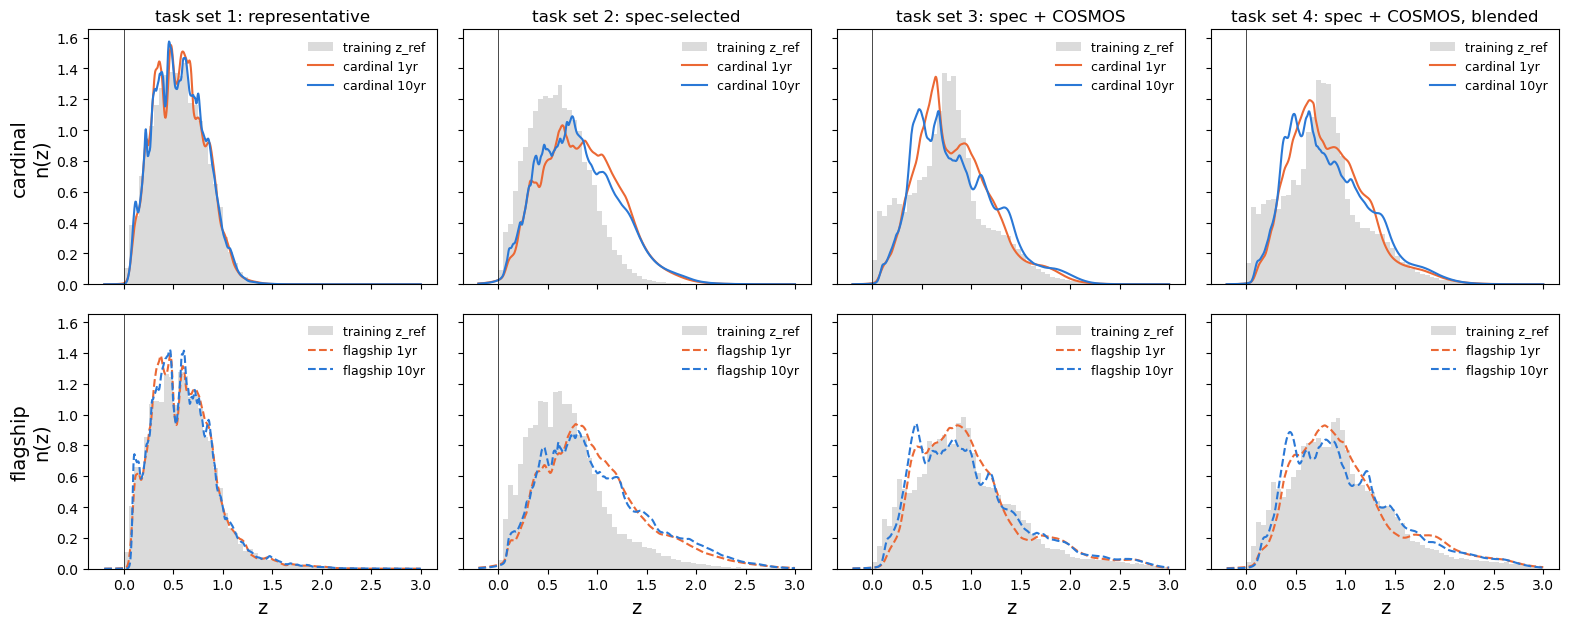

In [ ]:
zgrid = np.linspace(-0.2, 3.0, 641)


def stacked_nz(est):
    nz = np.zeros_like(zgrid)
    for chunk in np.array_split(np.arange(len(est)), 20):
        nz += norm.pdf(zgrid[None, :], est["mean"].to_numpy()[chunk, None], est["std"].to_numpy()[chunk, None]).sum(0)
    return nz / len(est)


fig, axes = plt.subplots(2, 4, figsize=(16, 6.5), sharex=True, sharey=True)
for col, taskset in enumerate(TASKSETS):
    for row, sim in enumerate(SIMS):
        ax = axes[row, col]
        ax.hist(train_z[(taskset, sim, "10yr")], bins=np.linspace(0, 3, 61), density=True,
                histtype="stepfilled", color=TRAIN_COLOR, alpha=0.35, label="training z_ref")
        for scenario in SCENARIOS:
            ax.plot(zgrid, stacked_nz(estimates[(taskset, sim, scenario)]), **style(sim, scenario))
        ax.axvline(0, color="k", lw=0.5)
        if row == 0:
            ax.set_title(f"task set {TASKSET_NAMES[taskset]}", fontsize=12)
        if row == 1:
            ax.set_xlabel("z")
        if col == 0:
            ax.set_ylabel(f"{sim}\nn(z)")
        ax.legend(fontsize=9, frameon=False)
fig.tight_layout()
plt.show()

# Part B: held-out scores

For each configuration the model file is reloaded and run on the held-out 20% of the training file. The model was trained on the other 80%, the same split as in the task-set notebooks. Each held-out set is scored on all of its objects and on the subsets the task-set notebook reported: task set 2 has `i > 23`, the faintest objects available, and task sets 3 and 4 have spec-selected and COSMOS-only.

Only task set 1 has a held-out set that is representative of its test set. For the other task sets these scores are **optimistic** for the test set.

In [ ]:
def heldout_predictions(taskset, sim, scenario):
    # Held-out reference z, i-mag, subset masks, and the ensemble's p(z) mean/std. Cached in CACHE_DIR.
    cache = os.path.join(CACHE_DIR, f"taskset_{taskset}_{sim}_{scenario}.npz")
    if os.path.exists(cache):
        return dict(np.load(cache))

    train = znn.read_catalog(path("training", taskset, sim, scenario))
    z_ref, subsets = reference_redshifts(train)
    _, idx_val = train_test_split(np.arange(len(train)), test_size=VAL_FRAC, random_state=SEED)
    val = train.iloc[idx_val]

    trained_models, features = znn.load_ensemble_file(path("pz_model", taskset, sim, scenario))
    errors = {col: f"{col}_err" for col, _ in features["bands"].values()}
    pz = znn.ensemble_predict_resampled(
        trained_models, val, errors, N_SAMPLES, np.random.default_rng(NOISE_SEED), **features
    )
    out = {
        "z_ref": z_ref[idx_val],
        "mag_i": val["mag_i_lsst"].to_numpy(),
        "mean": np.squeeze(pz.objdata["loc"]),
        "std": np.squeeze(pz.objdata["scale"]),
        **{f"subset:{name}": mask[idx_val] for name, mask in subsets.items()},
    }
    np.savez(cache, **out)
    return out


heldout = {}
for c in CONFIGS:
    print("held-out predictions:", *c)
    heldout[c] = heldout_predictions(*c)

held-out predictions: 1 cardinal 1yr
held-out predictions: 1 cardinal 10yr
held-out predictions: 1 flagship 1yr
held-out predictions: 1 flagship 10yr
held-out predictions: 2 cardinal 1yr
held-out predictions: 2 cardinal 10yr
held-out predictions: 2 flagship 1yr
held-out predictions: 2 flagship 10yr
held-out predictions: 3 cardinal 1yr
held-out predictions: 3 cardinal 10yr
held-out predictions: 3 flagship 1yr
held-out predictions: 3 flagship 10yr
held-out predictions: 4 cardinal 1yr
held-out predictions: 4 cardinal 10yr
held-out predictions: 4 flagship 1yr
held-out predictions: 4 flagship 10yr


In [ ]:
def challenge_metrics(z_ref, mean, std):
    # The challenge's seven scored metrics, computed as in the task-set notebooks.
    dz = (mean - z_ref) / (1 + z_ref)
    bias, _, scatter, _, abs_outlier_rate = znn.get_biweight_mean_sigma_outlier(dz)
    pit = PIT(znn.package_predictions(mean, std), z_ref)
    return {
        "mean": bias,
        "std": scatter,
        "abs_outlier_rate": abs_outlier_rate,
        "ks": pit.evaluate_PIT_KS().statistic,
        "CvM": pit.evaluate_PIT_CvM().statistic,
        "ksamp": pit.evaluate_PIT_anderson_ksamp().statistic,
        # qp derives this from a spline fit to the PIT quantiles and it breaks down (negative or huge values)
        # when PIT piles up at 0 or 1; the challenge evaluator uses the same call, so it is what gets scored
        "outlier": pit.evaluate_PIT_outlier_rate(),
        # what it is meant to measure, computed directly (not scored)
        "pit_outlier_direct": np.mean((pit.pit_samps < 0.0001) | (pit.pit_samps > 0.9999)),
    }, pit.pit_samps


def tier_points(values):
    return {name: sum(lo <= float(values[name]) <= hi for lo, hi in ranges) for name, ranges in scoring.metric_dict.items()}


results, pits = {}, {}
for c, h in heldout.items():
    for key in [k for k in h if k.startswith("subset:")]:
        m = h[key]
        results[(*c, key.removeprefix("subset:"))], pits[(*c, key.removeprefix("subset:"))] = challenge_metrics(
            h["z_ref"][m], h["mean"][m], h["std"][m]
        )

table = pd.DataFrame(results).T[list(scoring.metric_dict) + ["pit_outlier_direct"]]
table.index.names = ["taskset", "sim", "scenario", "subset"]
points = pd.DataFrame({k: tier_points(v) for k, v in results.items()}).T
points.index.names = table.index.names
points["total"] = points.sum(axis=1)
N_MAX = sum(len(r) for r in scoring.metric_dict.values())
table.round(4)

/home/jaimerzp/anaconda3/envs/qp/lib/python3.13/site-packages/qp/metrics/array_metrics.py:27: UserWarning: Parameter `variant` has been introduced to replace `midrank`; `midrank` will be removed in SciPy 1.19.0. Specify `variant` to silence this warning. Note that the returned object will no longer be unpackable as a tuple, and `critical_values` will be omitted.
  return stats.anderson_ksamp([p_random_variables, q_random_variables], **kwargs)
/home/jaimerzp/anaconda3/envs/qp/lib/python3.13/site-packages/qp/metrics/array_metrics.py:27: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  return stats.anderson_ksamp([p_random_variables, q_random_variables], **kwargs)


mean     std  abs_outlier_rate  \
taskset sim      scenario subset                                          
1       cardinal 1yr      all          0.0018  0.0186            0.0016   
                 10yr     all          0.0013  0.0124            0.0002   
        flagship 1yr      all          0.0008  0.0211            0.0011   
                 10yr     all         -0.0002  0.0135            0.0000   
2       cardinal 1yr      all          0.0044  0.0244            0.0093   
                          i > 23       0.0041  0.0398            0.0237   
                 10yr     all          0.0016  0.0150            0.0006   
                          i > 23      -0.0006  0.0196            0.0013   
        flagship 1yr      all          0.0009  0.0282            0.0076   
                          i > 23      -0.0027  0.0419            0.0176   
                 10yr     all         -0.0004  0.0160            0.0001   
                          i > 23      -0.0024  0.0195            0.0004   
3       cardinal 1yr      all          0.0035  0.0283            0.0520   
                          spec         0.0031  0.0181            0.0165   
                          COSMOS-only  0.0116  0.0893            0.1186   
                 10yr     all          0.0048  0.0200            0.0276   
                          spec         0.0041  0.0139            0.0015   
                          COSMOS-only  0.0103  0.0494            0.0728   
        flagship 1yr      all          0.0052  0.0409            0.0848   
                          spec         0.0045  0.0227            0.0039   
                          COSMOS-only  0.0115  0.0999            0.1587   
                 10yr     all          0.0015  0.0283            0.0445   
                          spec         0.0003  0.0159            0.0004   
                          COSMOS-only  0.0056  0.0516            0.0808   
4       cardinal 1yr      all          0.0050  0.0311            0.0537   
                          spec         0.0048  0.0208            0.0220   
                          COSMOS-only  0.0082  0.0851            0.1149   
                 10yr     all          0.0037  0.0203            0.0284   
                          spec         0.0035  0.0144            0.0063   
                          COSMOS-only  0.0048  0.0479            0.0690   
        flagship 1yr      all          0.0034  0.0425            0.0864   
                          spec         0.0036  0.0236            0.0049   
                          COSMOS-only  0.0066  0.0997            0.1587   
                 10yr     all          0.0016  0.0301            0.0508   
                          spec         0.0002  0.0170            0.0025   
                          COSMOS-only  0.0054  0.0567            0.0910   

                                            CvM       outlier      ks  \
taskset sim      scenario subset                                        
1       cardinal 1yr      all           70.7970  1.420000e-02  0.0950   
                 10yr     all           79.6564  1.590000e-02  0.1040   
        flagship 1yr      all           77.7673  3.260000e-02  0.1013   
                 10yr     all          126.7494 -5.380000e-01  0.1132   
2       cardinal 1yr      all          115.6140  1.490000e-02  0.1120   
                          i > 23        10.6097  8.200000e-03  0.0668   
                 10yr     all           79.0345  1.440000e-02  0.1021   
                          i > 23         6.3897  1.600000e-03  0.0527   
        flagship 1yr      all           69.8195  6.280000e-02  0.0947   
                          i > 23         9.7522  8.900000e-03  0.0537   
                 10yr     all          112.6079  3.670000e-02  0.1107   
                          i > 23        26.6583  9.600000e-03  0.0934   
3       cardinal 1yr      all          127.7000  1.739000e-01  0.1223   
                          spec          62.8677  1.190000e-02  0.1095   
                      

### Points against the challenge tiers

There is one point per nested range a metric falls inside, so at most 3 per metric and 21 per configuration (`pz_data_challenge.scoring.metric_dict`). The table uses the `all` held-out subset.

A 0 under `outlier` is usually not a real failure. qp computes that metric from a spline fit to the PIT quantiles, which breaks down (negative or huge values) when PIT piles up at 0 or 1, so compare with `pit_outlier_direct` in the table above. The challenge evaluator makes the same call, so these are the points it would award.

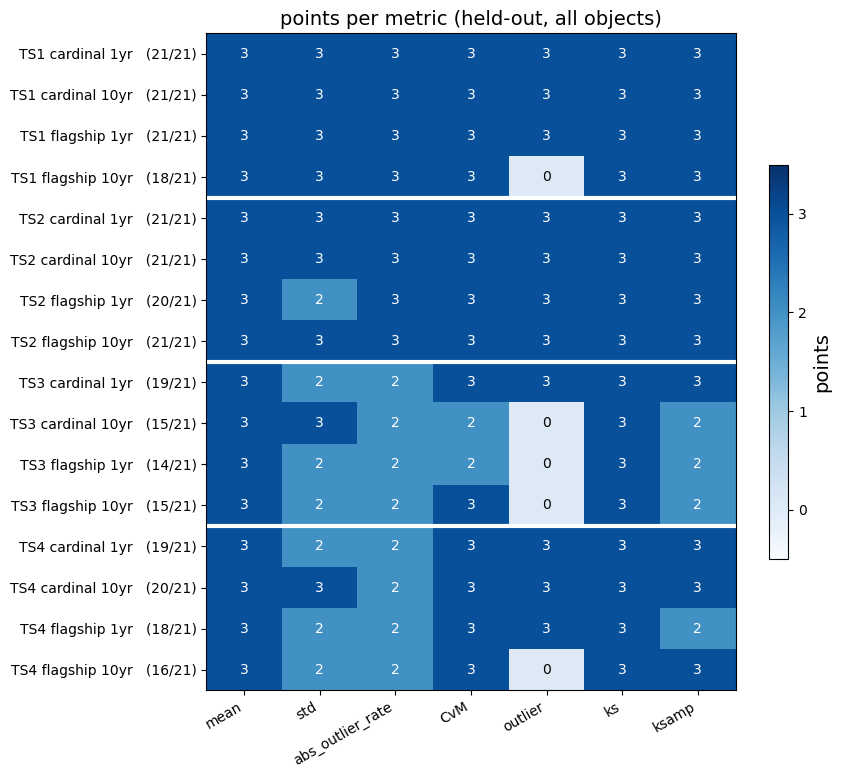

total points per task set (sum over its 4 configurations, held-out all):
taskset
1    81
2    83
3    63
4    73 
(out of 84 each)


In [ ]:
pts_all = points.xs("all", level="subset")
labels = [f"TS{t} {s} {y}" for t, s, y in pts_all.index]
metrics = list(scoring.metric_dict)

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(pts_all[metrics].to_numpy(), cmap="Blues", vmin=-0.5, vmax=3.5, aspect="auto")
for (i, j), v in np.ndenumerate(pts_all[metrics].to_numpy()):
    ax.text(j, i, int(v), ha="center", va="center", fontsize=10, color="white" if v >= 2 else "black")
ax.set_xticks(range(len(metrics)), metrics, rotation=30, ha="right")
ax.set_yticks(range(len(labels)), [f"{l}   ({t}/{N_MAX})" for l, t in zip(labels, pts_all["total"])])
for y in (3.5, 7.5, 11.5):
    ax.axhline(y, color="white", lw=3)
ax.set_title("points per metric (held-out, all objects)")
fig.colorbar(im, ax=ax, ticks=[0, 1, 2, 3], shrink=0.6, label="points")
fig.tight_layout()
plt.show()

print("total points per task set (sum over its 4 configurations, held-out all):")
print(pts_all["total"].groupby(level="taskset").sum().to_string(), f"\n(out of {4 * N_MAX} each)")

### Subsets

These are the same metrics on the task-set-specific subsets. Task set 2's `i > 23` subset is the closest proxy for its faint test set. In task sets 3 and 4, `COSMOS-only` is the faint, test-like part, scored against noisy many-band labels.

In [ ]:
sub = table.drop(index="all", level="subset")
sub_points = points.drop(index="all", level="subset")["total"].rename(f"points (/{N_MAX})")
pd.concat([sub, sub_points], axis=1).round(4)

mean     std  abs_outlier_rate  \
taskset sim      scenario subset                                          
2       cardinal 1yr      i > 23       0.0041  0.0398            0.0237   
                 10yr     i > 23      -0.0006  0.0196            0.0013   
        flagship 1yr      i > 23      -0.0027  0.0419            0.0176   
                 10yr     i > 23      -0.0024  0.0195            0.0004   
3       cardinal 1yr      spec         0.0031  0.0181            0.0165   
                          COSMOS-only  0.0116  0.0893            0.1186   
                 10yr     spec         0.0041  0.0139            0.0015   
                          COSMOS-only  0.0103  0.0494            0.0728   
        flagship 1yr      spec         0.0045  0.0227            0.0039   
                          COSMOS-only  0.0115  0.0999            0.1587   
                 10yr     spec         0.0003  0.0159            0.0004   
                          COSMOS-only  0.0056  0.0516            0.0808   
4       cardinal 1yr      spec         0.0048  0.0208            0.0220   
                          COSMOS-only  0.0082  0.0851            0.1149   
                 10yr     spec         0.0035  0.0144            0.0063   
                          COSMOS-only  0.0048  0.0479            0.0690   
        flagship 1yr      spec         0.0036  0.0236            0.0049   
                          COSMOS-only  0.0066  0.0997            0.1587   
                 10yr     spec         0.0002  0.0170            0.0025   
                          COSMOS-only  0.0054  0.0567            0.0910   

                                            CvM       outlier      ks  \
taskset sim      scenario subset                                        
2       cardinal 1yr      i > 23        10.6097  8.200000e-03  0.0668   
                 10yr     i > 23         6.3897  1.600000e-03  0.0527   
        flagship 1yr      i > 23         9.7522  8.900000e-03  0.0537   
                 10yr     i > 23        26.6583  9.600000e-03  0.0934   
3       cardinal 1yr      spec          62.8677  1.190000e-02  0.1095   
                          COSMOS-only   78.6923  1.971049e+02  0.1710   
                 10yr     spec         191.6273  1.940000e-02  0.1789   
                          COSMOS-only  117.6472 -5.640706e+15  0.2052   
        flagship 1yr      spec         122.6576  2.940000e-02  0.1814   
                          COSMOS-only  138.2544 -1.460195e+02  0.1866   
                 10yr     spec          94.5261 -1.607580e+01  0.1600   
                          COSMOS-only  142.1891  1.910989e+05  0.1864   
4       cardinal 1yr      spec         168.7127  2.310000e-02  0.1772   
                          COSMOS-only   73.2865  1.028897e+03  0.1675   
                 10yr     spec         160.7908  3.480000e-02  0.1698   
                          COSMOS-only   61.4593  4.197590e+09  0.1555   
        flagship 1yr      spec          86.3433 -1.830000e-02  0.1501   
                          COSMOS-only  131.4150  2.157000e-01  0.1818   
                 10yr     spec          60.4208 -3.333860e+01  0.1285   
                          COSMOS-only  134.3466  3.340036e+04  0.1870   

                                          ksamp  pit_outlier_direct  \
taskset sim      scenario subset                                      
2       cardinal 1yr      i > 23        36.6721              0.0080   
                 10yr     i > 23        38.0772              0.0056   
        flagship 1yr      i > 23        50.9424              0.0090   
                 10yr     i > 23       124.0719              0.0127   
3       cardinal 1yr      spec         232.2075              0.0137   
                          COSMOS-only  364.1943              0.0746   
                 10yr     spec         720.1031              0.0312   
                          COSMOS-only  501.2397              0.1021   
        flagship 1yr      spec         514.5566              0.0391   
  

### PIT

PIT histograms on the `all` held-out subset. A flat histogram means the p(z) is calibrated. A U shape means it is too narrow, and a hump means it is too wide.

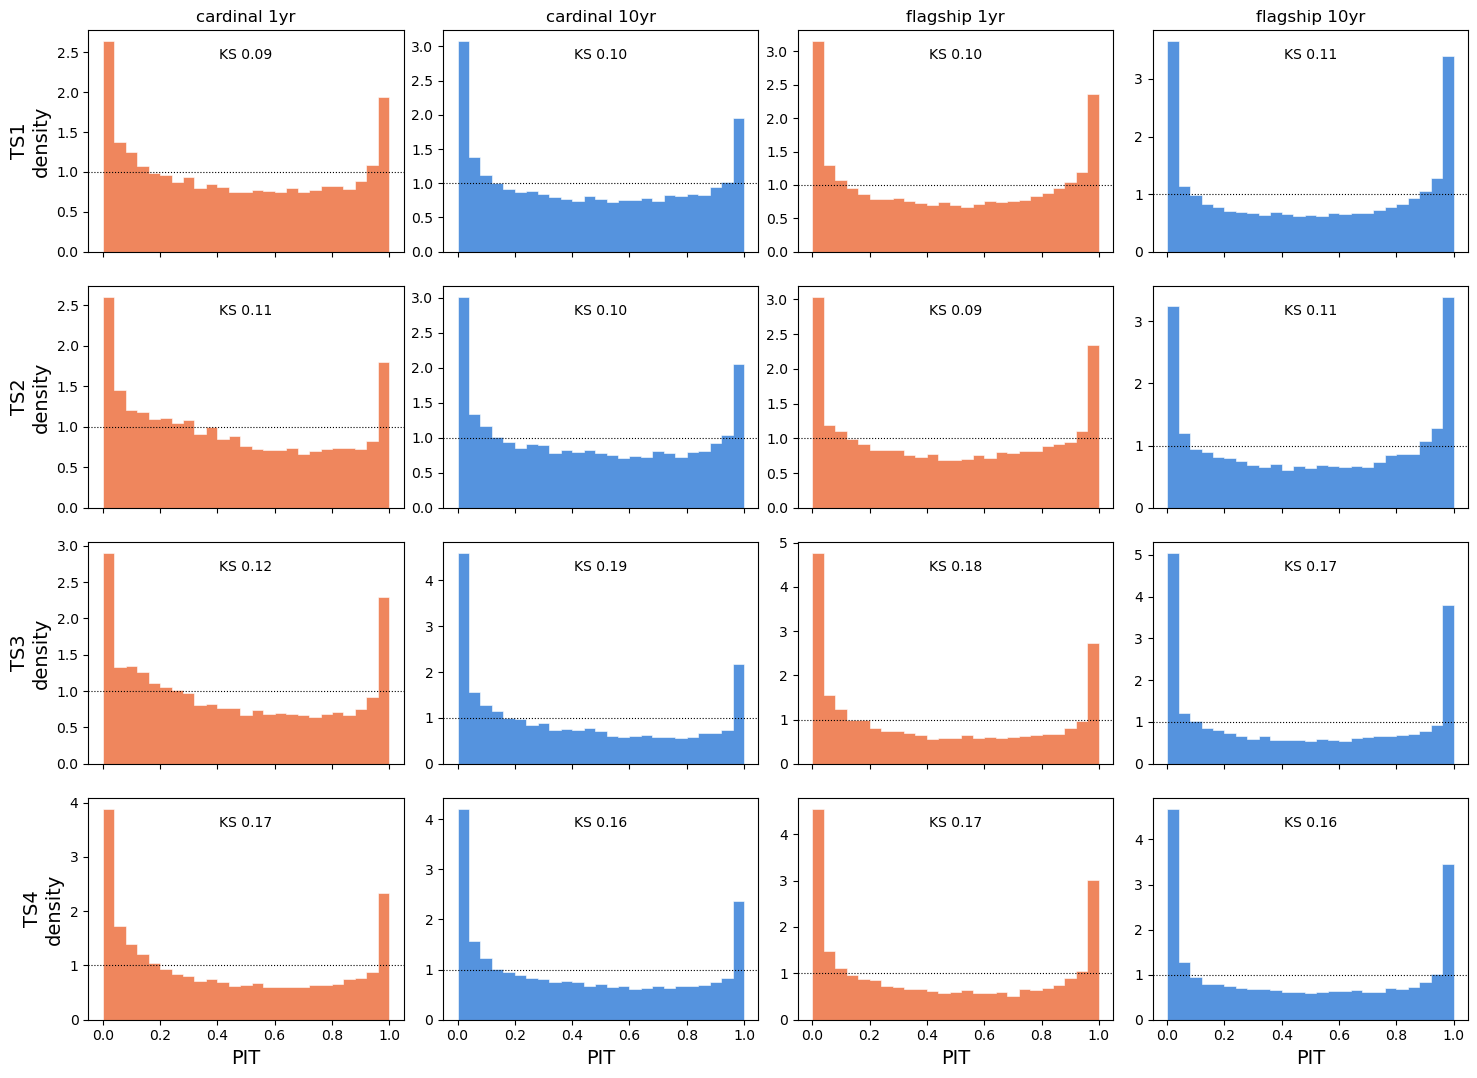

In [ ]:
pit_bins = np.linspace(0, 1, 26)
fig, axes = plt.subplots(4, 4, figsize=(15, 11), sharex=True)
for row, taskset in enumerate(TASKSETS):
    for col, (sim, scenario) in enumerate(itertools.product(SIMS, SCENARIOS)):
        ax = axes[row, col]
        ax.hist(pits[(taskset, sim, scenario, "all")], pit_bins, density=True, color=COLORS[scenario],
                histtype="stepfilled", alpha=0.8, ec="white", lw=0.5)
        ax.axhline(1, color="k", lw=0.8, ls=":")
        ks = table.loc[(taskset, sim, scenario, "all"), "ks"]
        ax.text(0.5, 0.92, f"KS {ks:.2f}", transform=ax.transAxes, ha="center", va="top", fontsize=10)
        if row == 0:
            ax.set_title(f"{sim} {scenario}", fontsize=12)
        if col == 0:
            ax.set_ylabel(f"TS{taskset}\ndensity")
        if row == 3:
            ax.set_xlabel("PIT")
fig.tight_layout()
plt.show()

### Point estimates

`zmode` against the reference redshift on the `all` held-out subset (log-density 2D histogram). The dashed lines mark |Δz|/(1+z) = 0.2, the outlier threshold.

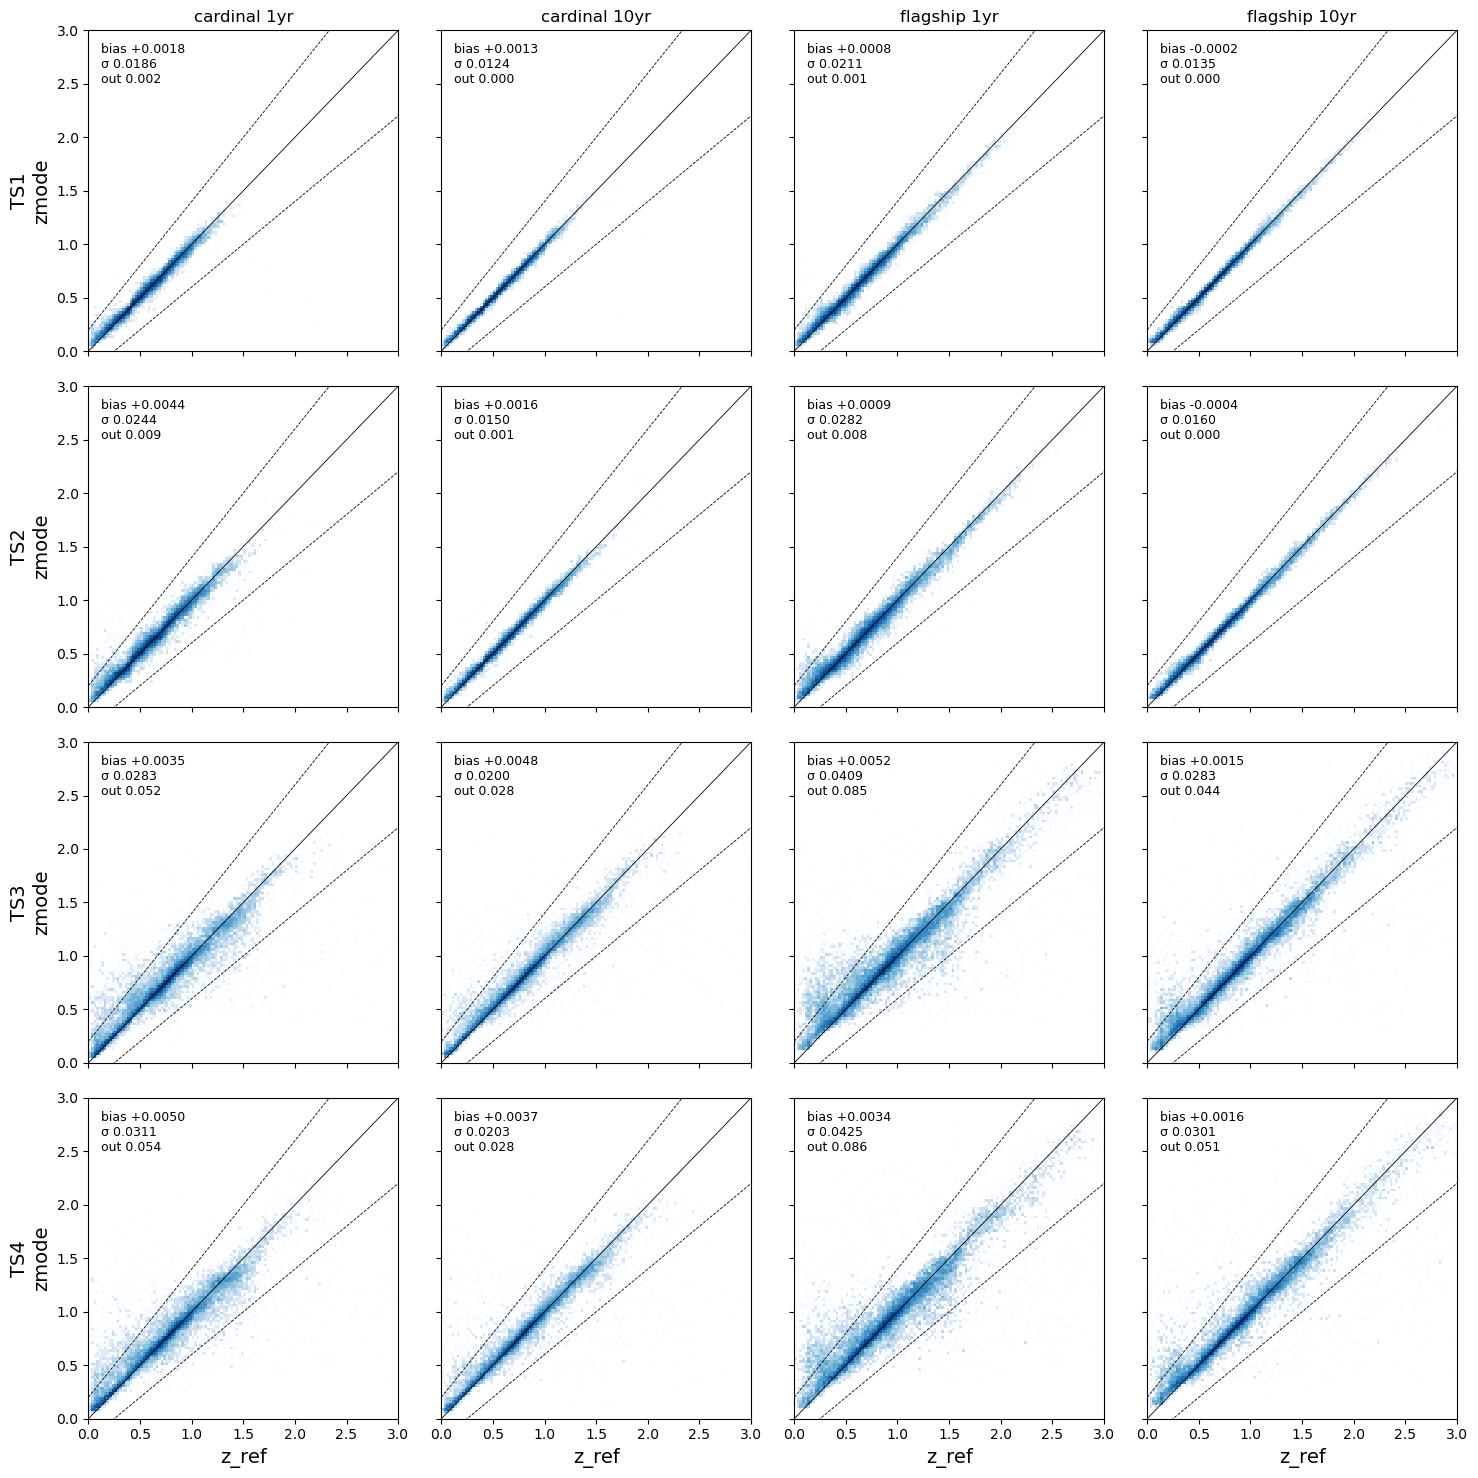

In [ ]:
from matplotlib.colors import LogNorm

zb = np.linspace(0, 3, 121)
fig, axes = plt.subplots(4, 4, figsize=(15, 15), sharex=True, sharey=True)
for row, taskset in enumerate(TASKSETS):
    for col, (sim, scenario) in enumerate(itertools.product(SIMS, SCENARIOS)):
        ax = axes[row, col]
        h = heldout[(taskset, sim, scenario)]
        ax.hist2d(h["z_ref"], h["mean"], bins=[zb, zb], cmap="Blues", norm=LogNorm(), rasterized=True)
        ax.plot(zb, zb, color="k", lw=0.6)
        for sgn in (-1, 1):
            ax.plot(zb, zb + sgn * 0.2 * (1 + zb), color="k", lw=0.6, ls="--")
        v = table.loc[(taskset, sim, scenario, "all")]
        ax.text(0.04, 0.96, f"bias {v['mean']:+.4f}\nσ {v['std']:.4f}\nout {v['abs_outlier_rate']:.3f}",
                transform=ax.transAxes, va="top", fontsize=9)
        ax.set_xlim(0, 3)
        ax.set_ylim(0, 3)
        if row == 0:
            ax.set_title(f"{sim} {scenario}", fontsize=12)
        if col == 0:
            ax.set_ylabel(f"TS{taskset}\nzmode")
        if row == 3:
            ax.set_xlabel("z_ref")
fig.tight_layout()
plt.show()

# Appendix: what the CNN sees

The model does not take the band magnitudes as a list. Each magnitude (minus the reference i band) is spread over wavelength with its filter curve, and the result is averaged into `n_bins` equal-width wavelength bins. This gives a continuous curve (channel 0 of `X`), which is shown here for a few held-out galaxies across redshift.

- **Left:** the encoding of the catalogue photometry, drawn through the `n_bins` bin centres as in `znn.visualize_the_data`. The shaded band is the 16–84% range over `N_DRAWS` photometric resamplings, i.e. the noise the ensemble sees at prediction time. The filter curves are in the strip on top. Bins with no observed band are 0 (and have 0 in the coverage channel).
- **Right:** the predicted p(z) for that galaxy from Part B, with the reference redshift as a dashed line.

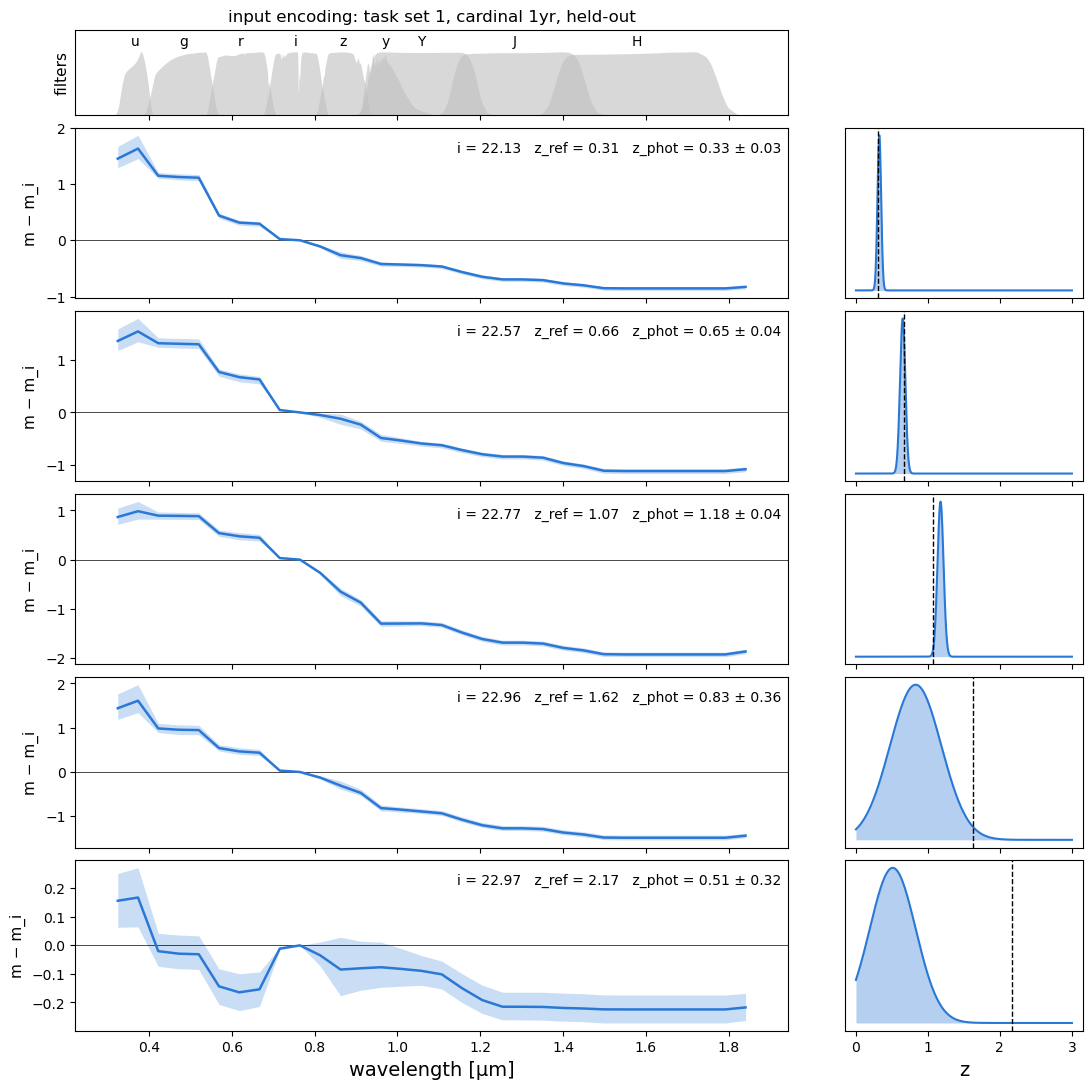

In [ ]:
EXAMPLE = (1, "cardinal", "1yr")  # (task set, sim, depth); 1yr makes the photometric errors easier to see
Z_TARGETS = [0.3, 0.7, 1.1, 1.6, 2.2]  # one galaxy picked near each reference redshift
IMAG_RANGE = (22.0, 23.5)  # faint enough for the errors to show
N_DRAWS = 200
rng = np.random.default_rng(1)

train = znn.read_catalog(path("training", *EXAMPLE))
_, idx_val = train_test_split(np.arange(len(train)), test_size=VAL_FRAC, random_state=SEED)
h = heldout[EXAMPLE]
_, features = znn.load_ensemble_file(path("pz_model", *EXAMPLE))
bands, curves, cfg = features["bands"], features["filter_curves"], features["config"]
errors = {col: f"{col}_err" for col, _ in bands.values()}

in_mag = (h["mag_i"] > IMAG_RANGE[0]) & (h["mag_i"] < IMAG_RANGE[1])
picks = [rng.choice(np.flatnonzero(in_mag & (np.abs(h["z_ref"] - zt) < 0.05))) for zt in Z_TARGETS]
gal = train.iloc[idx_val[picks]]

# wavelength bin centres, as catalog_to_XY builds them
lambda_common = np.linspace(min(c[:, 0].min() for c in curves.values()), max(c[:, 0].max() for c in curves.values()), cfg["n_lambda"])
lam_bins, _ = znn.make_lambda_bins(lambda_common, cfg["n_bins"])
lam_eff = {b: np.sum(c[:, 0] * c[:, 1]) / np.sum(c[:, 1]) for b, c in curves.items()}

X_obs, _ = znn.catalog_to_XY(gal, **features)
enc_draws = [znn.catalog_to_XY(znn.resample_photometry(gal, errors, rng), **features)[0][..., 0] for _ in range(N_DRAWS)]
enc_lo, enc_hi = np.percentile(enc_draws, [16, 84], axis=0)

ENC = "#2a78d6"
um = 1e-4  # filter curves are in Angstrom
fig, axes = plt.subplots(
    len(picks) + 1, 2, figsize=(13, 2.3 * len(picks) + 1.5), sharex="col",
    gridspec_kw=dict(height_ratios=[0.5] + [1] * len(picks), width_ratios=[3, 1], hspace=0.08, wspace=0.12),
)
for b, c in curves.items():
    axes[0, 0].fill_between(c[:, 0] * um, c[:, 1] / c[:, 1].max(), color="0.75", alpha=0.6, lw=0)
    axes[0, 0].text(lam_eff[b] * um, 1.05, b, ha="center", va="bottom", fontsize=10)
axes[0, 0].set_ylim(0, 1.35)
axes[0, 0].set_yticks([])
axes[0, 0].set_ylabel("filters", fontsize=11)
axes[0, 1].axis("off")

zg = np.linspace(0, 3, 601)
for row, (k, j) in enumerate(zip(range(len(picks)), picks), start=1):
    ax = axes[row, 0]
    ax.axhline(0, color="k", lw=0.5)
    ax.fill_between(lam_bins * um, enc_lo[k], enc_hi[k], color=ENC, alpha=0.25, lw=0)
    ax.plot(lam_bins * um, X_obs[k, :, 0], color=ENC, lw=1.8)
    ax.set_ylabel("m − m_i", fontsize=11)
    ax.text(0.99, 0.92, f"i = {h['mag_i'][j]:.2f}   z_ref = {h['z_ref'][j]:.2f}   z_phot = {h['mean'][j]:.2f} ± {h['std'][j]:.2f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=10)

    ax = axes[row, 1]
    ax.fill_between(zg, norm.pdf(zg, h["mean"][j], h["std"][j]), color=ENC, alpha=0.35, lw=0)
    ax.plot(zg, norm.pdf(zg, h["mean"][j], h["std"][j]), color=ENC, lw=1.5)
    ax.axvline(h["z_ref"][j], color="k", ls="--", lw=1)
    ax.set_yticks([])
axes[-1, 0].set_xlabel("wavelength [μm]")
axes[-1, 1].set_xlabel("z")
axes[0, 0].set_title(f"input encoding: task set {EXAMPLE[0]}, {EXAMPLE[1]} {EXAMPLE[2]}, held-out", fontsize=12)
plt.show()